## MISA (2024-2025)
- Alohan'ny mamerina dia avereno atao Run ny notebook iray manontolo. Ny fanaovana azy dia redémarrena mihitsy ny kernel aloha (jereo menubar, safidio **Kernel$\rightarrow$Restart Kernel and Run All Cells**).

- Izay misy hoe `YOUR CODE HERE` na `YOUR ANSWER HERE` ihany no fenoina. Afaka manampy cells vaovao raha ilaina. Aza adino ny mameno references eo ambany raha ilaina.

## References
Eto ilay references rehetra no apetraka

---

In [1]:
# AZA MANAMPY CODE ATO FA MNAOVA CELLULE VAOVAO

from random import randrange
import numpy as np
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.datasets import load_diabetes, load_iris, load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

# K-Nearest Neighbor

## Computing distances

In [2]:
data = load_digits()
X_train3, y_train3 = data.data, data.target
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_train3, y_train3, test_size=0.33, random_state=2)

def get_distances_two_loops_with_norm(X_train, X_test):
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))
    for i in range(num_test):
        for j in range(num_train):
            distances[i, j] = np.linalg.norm(X_test[i] - X_train[j])
    return distances

In [ ]:
def get_distances_two_loops(X_train, X_test):
    """
    Compute the distance between each test point in X_test and each training point
    in X_train 

    Inputs:
    - X_test: array of shape (num_test, D) 

    Returns:
    - distances: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
    the ith test point and the jth training point.
    """
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))
    for i in range(num_test):
        for j in range(num_train):
            diff = X_test[i] - X_train[j]
            distances[i, j] = np.sqrt(np.sum(diff ** 2))
    return distances

In [4]:
distances = get_distances_two_loops(X_train3, X_test3)
true_distances = get_distances_two_loops_with_norm(X_train3, X_test3)

difference = np.linalg.norm(distances - true_distances, ord='fro')

print(difference)
assert difference < 1e-10

0.0


In [ ]:
def compute_distances_one_loop(X_train, X_test):
    """
    Compute the distance between each test point in X_test and each training point
    in X_train 

    Inputs:
    - X_test: array of shape (num_test, D) 

    Returns:
    - dists: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
    the ith test point and the jth training point.
    """
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))
    for i in range(num_test):
        diff = X_test[i] - X_train  # shape (num_train, D)
        distances[i] = np.sqrt(np.sum(diff ** 2, axis=1))
    return distances    

In [6]:
distances = compute_distances_one_loop(X_train3, X_test3)
true_distances = get_distances_two_loops_with_norm(X_train3, X_test3)

difference = np.linalg.norm(distances - true_distances, ord='fro')

print(difference)
assert difference < 1e-10

0.0


In [ ]:
def get_distances_zero_loop(X_train, X_test):
    """
    Compute the distance between each test point in X_test and each training point
    in X_train 

    Inputs:
    - X_test: array of shape (num_test, D) 

    Returns:
    - distances: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
    the ith test point and the jth training point.
    """
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))  

    test_sq = np.sum(X_test ** 2, axis=1, keepdims=True)   # (num_test, 1)
    train_sq = np.sum(X_train ** 2, axis=1, keepdims=True)  # (num_train, 1)
    cross = X_test @ X_train.T                              # (num_test, num_train)
    distances = np.sqrt(np.maximum(test_sq + train_sq.T - 2 * cross, 0))
    
    return distances

In [8]:
distances = get_distances_zero_loop(X_train3, X_test3)
true_distances = get_distances_two_loops_with_norm(X_train3, X_test3)

difference = np.linalg.norm(distances - true_distances, ord='fro')

print(difference)
assert difference < 1e-10

0.0


## K-Nearest Neighbor (knn) classifier

In [ ]:
class KNearestNeighborClassifier():
    """ kNN classifier using L2 distance """

    def __init__(self, k=1):
        """
        Inputs:
        - k: number of nearest neighbors that vote for the predicted labels.
        """
        self.k = k

    def fit(self, X, y):
        """
        Train the classifier. Just memorize the training data.

        Inputs:
        - X: array of shape (num_train, D) 
        - y: array of shape (N,) 
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        """
        Predict labels for test data using this classifier.

        Inputs:
        - X: array of shape (num_test, D) 

        Returns:
        - y: array of shape (num_test,) 
        """
        distances = get_distances_zero_loop(self.X_train, X)
        return self.predict_labels(distances)

    def predict_labels(self, distances):
        """
        Given a matrix of distances between test points and training points,
        predict a label for each test point.

        - distances: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
        the ith test point and the jth training point.

        Returns:
        - y:  array of shape (num_test,) 
        """
        num_test = distances.shape[0]
        y_pred = np.zeros(num_test)
        for i in range(num_test):
            # list storing the labels of the k nearest neighbors to the ith test point.
            closest_y = []

            k_nearest_idx = np.argsort(distances[i])[:self.k]
            closest_y = self.y_train[k_nearest_idx]

            labels, counts = np.unique(closest_y, return_counts=True)
            y_pred[i] = labels[np.argmax(counts)]

        return y_pred

In [10]:
sk_model = KNeighborsClassifier(n_neighbors=3)
sk_model.fit(X_train3, y_train3)
sk_pred = sk_model.predict(X_test3)
sk_accuracy = accuracy_score(y_test3, sk_pred)

model = KNearestNeighborClassifier(k=3)
model.fit(X_train3, y_train3)
pred = model.predict(X_test3)
model_accuracy = accuracy_score(y_test3, pred)

print("Accuracy scikit-learn:", sk_accuracy)
print("Accuracy gradient descent model :", model_accuracy)
assert sk_accuracy - model_accuracy < 1e-10

Accuracy scikit-learn: 0.9831649831649831
Accuracy gradient descent model : 0.9831649831649831


## cross-validation

In [ ]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []


X_train_folds = np.array_split(X_train3, num_folds)
y_train_folds = np.array_split(y_train3, num_folds)

# A dictionary of length num_folds holding the accuracies for different values of k 
k_to_accuracies = {}

# k-fold cross validation 
for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):
        X_val = X_train_folds[fold]
        y_val = y_train_folds[fold]
        X_tr = np.concatenate([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_tr = np.concatenate([y_train_folds[i] for i in range(num_folds) if i != fold])
        
        clf = KNearestNeighborClassifier(k=k)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        k_to_accuracies[k].append(acc)

In [12]:
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.991701
k = 1, accuracy = 0.983402
k = 1, accuracy = 0.983402
k = 1, accuracy = 0.970833
k = 1, accuracy = 0.995833
k = 3, accuracy = 0.987552
k = 3, accuracy = 0.983402
k = 3, accuracy = 0.987552
k = 3, accuracy = 0.970833
k = 3, accuracy = 0.983333
k = 5, accuracy = 0.991701
k = 5, accuracy = 0.983402
k = 5, accuracy = 0.987552
k = 5, accuracy = 0.975000
k = 5, accuracy = 0.987500
k = 8, accuracy = 0.979253
k = 8, accuracy = 0.970954
k = 8, accuracy = 0.987552
k = 8, accuracy = 0.966667
k = 8, accuracy = 0.983333
k = 10, accuracy = 0.983402
k = 10, accuracy = 0.970954
k = 10, accuracy = 0.979253
k = 10, accuracy = 0.966667
k = 10, accuracy = 0.975000
k = 12, accuracy = 0.979253
k = 12, accuracy = 0.975104
k = 12, accuracy = 0.979253
k = 12, accuracy = 0.958333
k = 12, accuracy = 0.979167
k = 15, accuracy = 0.983402
k = 15, accuracy = 0.962656
k = 15, accuracy = 0.983402
k = 15, accuracy = 0.966667
k = 15, accuracy = 0.958333
k = 20, accuracy = 0.970954
k = 20, accu

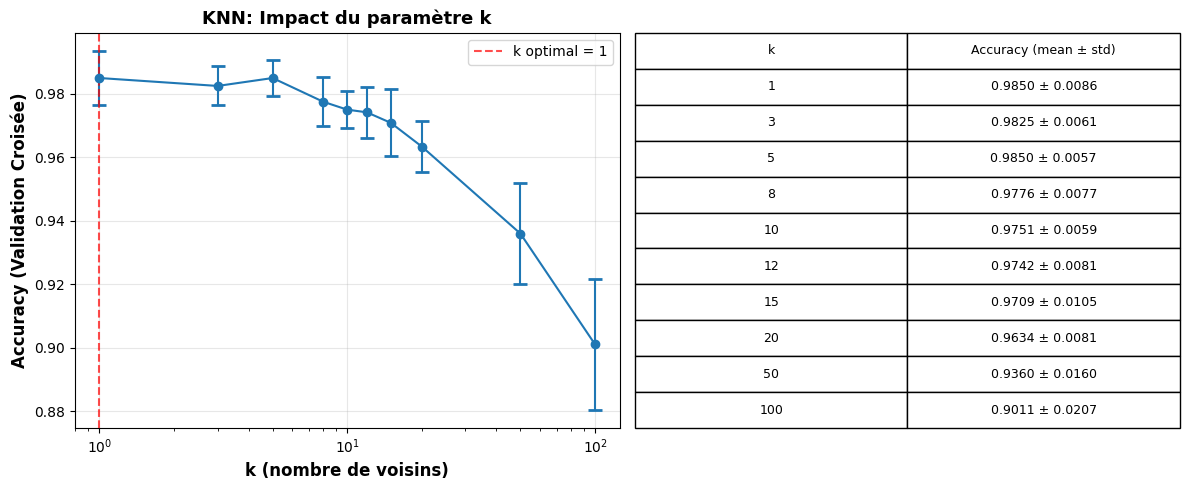

RÉSUMÉ DU K-FOLD CROSS VALIDATION
Nombre de folds: 5
k optimal trouvé: 1
Meilleure accuracy: 0.9850


In [14]:
import matplotlib.pyplot as plt

# Visualiser les résultats du cross-validation
plt.figure(figsize=(12, 5))

# Calculer les moyennes et écarts-types des accuracies
mean_accuracies = []
std_accuracies = []

for k in sorted(k_to_accuracies.keys()):
    accuracies = k_to_accuracies[k]
    mean_accuracies.append(np.mean(accuracies))
    std_accuracies.append(np.std(accuracies))

k_values = sorted(k_to_accuracies.keys())

# Graphique 1: Accuracies vs k
plt.subplot(1, 2, 1)
plt.errorbar(k_values, mean_accuracies, yerr=std_accuracies, marker='o', capsize=5, capthick=2)
plt.xlabel('k (nombre de voisins)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (Validation Croisée)', fontsize=12, fontweight='bold')
plt.title('KNN: Impact du paramètre k', fontsize=13, fontweight='bold')
plt.xscale('log')
plt.grid(True, alpha=0.3)

# Trouver le k optimal
best_k_idx = np.argmax(mean_accuracies)
best_k = k_values[best_k_idx]
best_accuracy = mean_accuracies[best_k_idx]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'k optimal = {best_k}')
plt.legend()

# Graphique 2: Tableau des résultats
plt.subplot(1, 2, 2)
plt.axis('off')
table_data = []
for k in sorted(k_to_accuracies.keys()):
    acc_mean = np.mean(k_to_accuracies[k])
    acc_std = np.std(k_to_accuracies[k])
    table_data.append([f'{k}', f'{acc_mean:.4f} ± {acc_std:.4f}'])

table = plt.table(cellText=table_data, 
                  colLabels=['k', 'Accuracy (mean ± std)'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

print("="*60)
print("RÉSUMÉ DU K-FOLD CROSS VALIDATION")
print("="*60)
print(f"Nombre de folds: {num_folds}")
print(f"k optimal trouvé: {best_k}")
print(f"Meilleure accuracy: {best_accuracy:.4f}")
print("="*60)